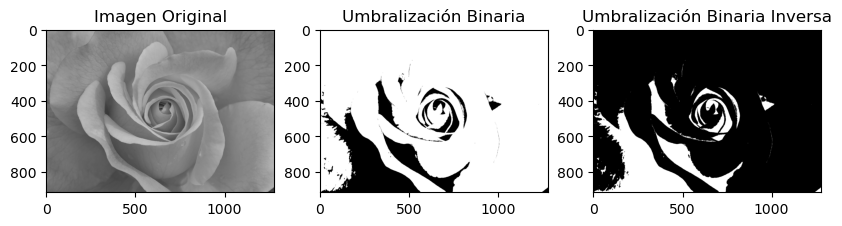

In [13]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('imagen4.jpg',0)#lee en escala de grises
#umbralizacion binaria
_,umbral_binario=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)
#umbralizacion binaria inversa
_,umbral_binario_inv=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(imagen,cmap='gray')
plt.title('Imagen Original')
plt.subplot(1,3,2)
plt.imshow(umbral_binario,cmap='gray')
plt.title('Umbralización Binaria')
plt.subplot(1,3,3)
plt.imshow(umbral_binario_inv,cmap='gray')
plt.title('Umbralización Binaria Inversa')
plt.show()

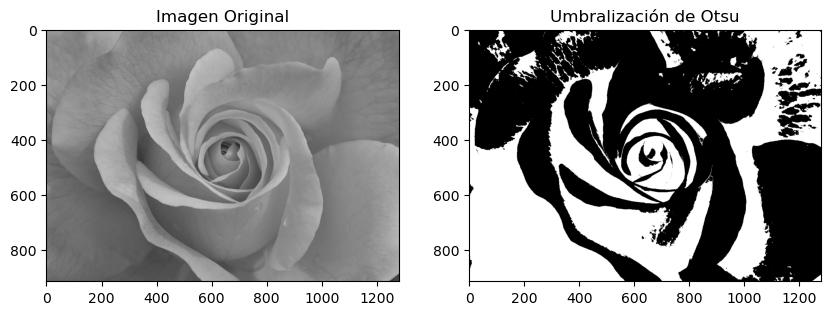

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread("imagen4.jpg",0)#escala de grises
_,otsu=cv2.threshold(image,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
imagen_fin=np.where(image>otsu,255,0).astype(np.uint8)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title("Imagen Original")
plt.subplot(1,2,2)
plt.imshow(imagen_fin,cmap='gray')
plt.title("Umbralización de Otsu")
plt.show()


UMBRALIZACION VARIABLE PARTICION DE UNA IMAGEN

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def variable_part(image,tam_bloque,c):
    umbral_img=np.zeros_like(image)
    for y in range(0,image.shape[0],tam_bloque):#recorremos filas
        for x in range(0,image.shape[1],tam_bloque):#recorremos columnas
            bloque=image[y:y+tam_bloque,x:x+tam_bloque]#vemos el bloque
            bloq_media=np.mean(bloque)#intensidad del bloque
            umbral=bloq_media-c
            umbral_img[y:y+tam_bloque,x:x+tam_bloque]=[bloque>umbral]+255#umb binario
    return umbral_img
tam_b=25
c=10
image=cv2.imread('imagen4.jpg',0)
img_fin=variable_part(image,tam_b,c)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title("Imagen Original")
plt.subplot(1,2,2)
plt.imshow(img_fin,cmap='gray')
plt.title("Umbralización Variable")
plt.show()

TypeError: can only concatenate list (not "int") to list

PROPIEDADES LOCALES

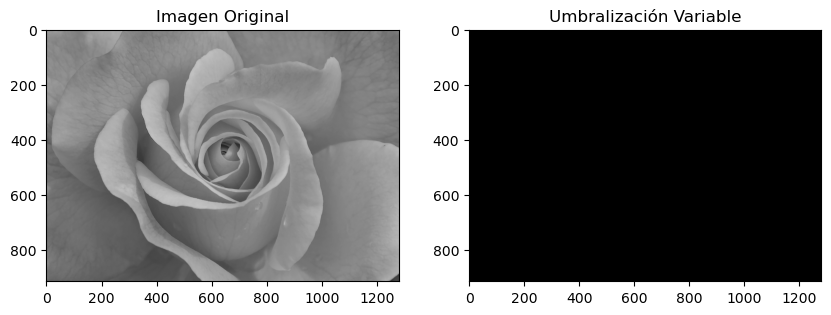

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread("imagen4.jpg",0)#escala de grises
def local(image,tamanio_ventana,k):
    umbr_img=np.zeros_like(image)
    #definir un rastreo de imagen con padding
    pad=tamanio_ventana//2
    padded_image=cv2.copyMakeBorder(image,pad,pad,pad,pad,cv2.BORDER_REPLICATE)
    #RECORREMOS CADA PIXEL
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana=padded_image[y:y:+tamanio_ventana,x:x+tamanio_ventana]
            #calculo de nedua y desv
            mean_local=np.mean(ventana)
            std_mean=np.std(ventana)
            #calculo del umbral
            umbral=mean_local-(k*std_mean)
            umbr_img[y,x]=255 if image[y,x]>umbral else 0
    return umbr_img
tam_vent=15
k=2
img_fin=local(image,tam_vent,k)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title("Imagen Original")
plt.subplot(1,2,2)
plt.imshow(img_fin,cmap='gray')
plt.title("Umbralización Variable")
plt.show()

UMBRAL CON OPEN CV

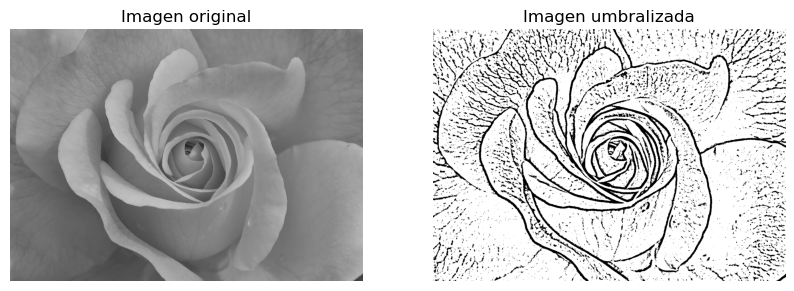

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread("imagen4.jpg",0)#escala de grises

ventana=15
k=2
img_fin=cv2.adaptiveThreshold(image,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,ventana,k)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Imagen original")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Imagen umbralizada")
plt.imshow(img_fin, cmap="gray")
plt.axis("off")

plt.show()

Umbral encontrado: 148


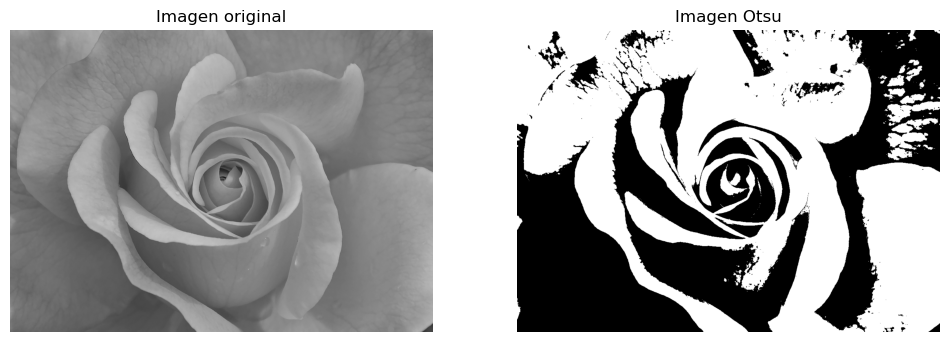

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("imagen4.jpg",0)#escala de grises

hist = cv2.calcHist([image],[0],None,[256],[0,256])
hist = hist.ravel()
prob = hist / hist.sum()

m = np.cumsum(prob)           
m_a = np.cumsum(prob * np.arange(256)) 
d_m = m_a[-1]
sigma_b = (d_m * m - m_a)**2 / (m * (1 - m) + 1e-10)

T = np.argmax(sigma_b)

_, img_otsu = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)

print("Umbral encontrado:", T)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Imagen original")
plt.imshow(image,cmap="gray")
plt.axis("off")


plt.subplot(1,2,2)
plt.title("Imagen Otsu")
plt.imshow(img_otsu,cmap="gray")
plt.axis("off")

plt.show()